In [70]:
import NeuralImplicit as NI
import network_defs as net_defs
import torch
import importlib
import matplotlib.pyplot as plt
importlib.reload(net_defs)
importlib.reload(NI)
#set torch default dtype to float64
torch.set_default_dtype(torch.float64)


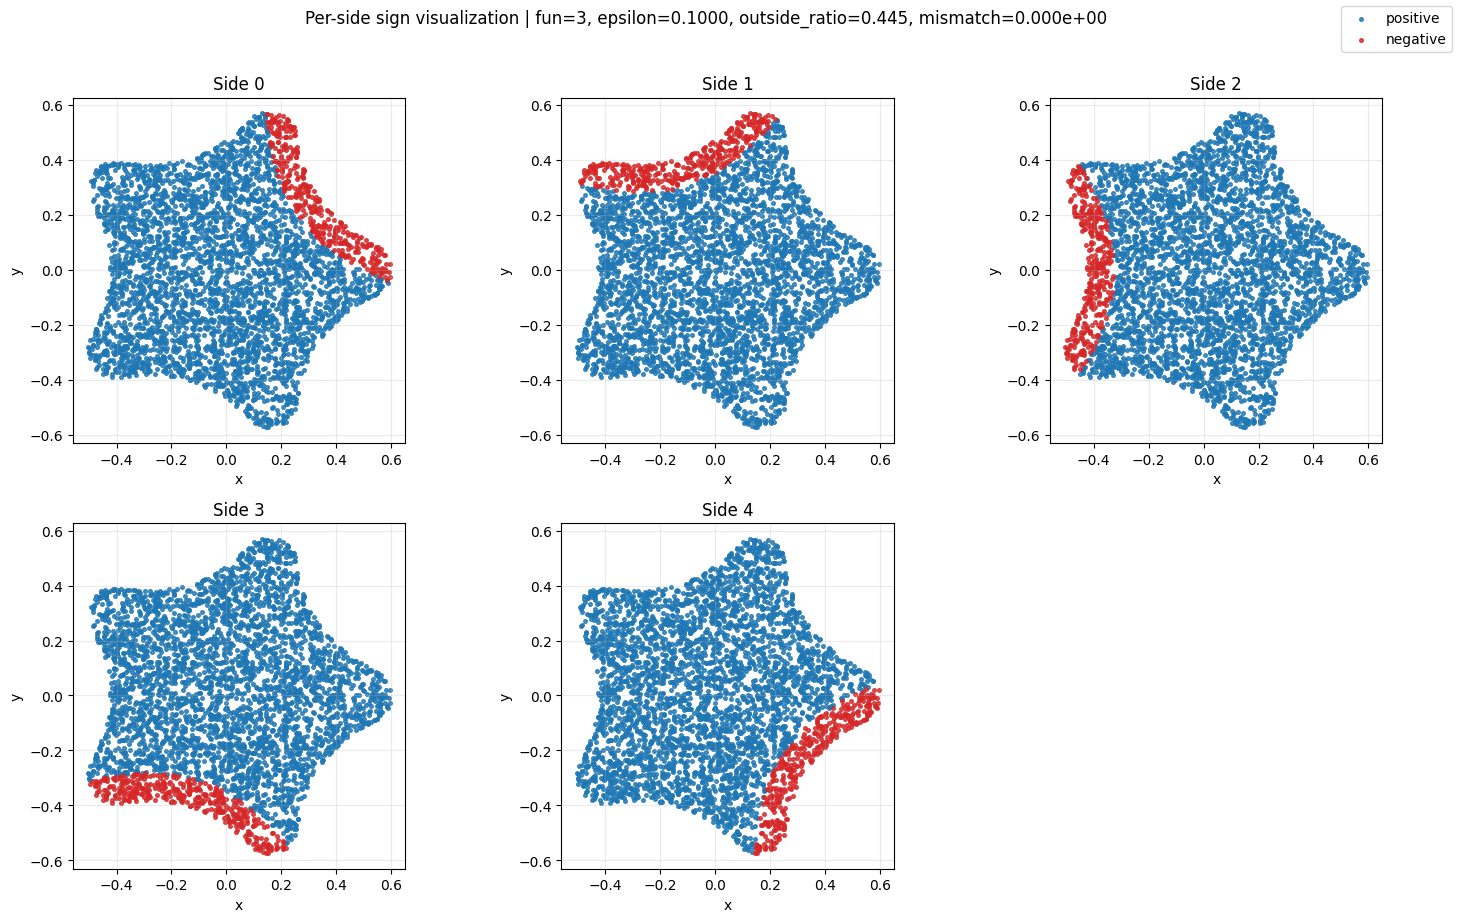

(<Figure size 1500x900 with 6 Axes>,
 array([[<Axes: title={'center': 'Side 0'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Side 1'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Side 2'}, xlabel='x', ylabel='y'>],
        [<Axes: title={'center': 'Side 3'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Side 4'}, xlabel='x', ylabel='y'>,
         <Axes: >]], dtype=object),
 {'batch_size': 4000,
  'fun_num': 3,
  'epsilon': 0.1,
  'n_sides_out': 5,
  'outside_ratio': 0.4449999928474426,
  'mismatch_ratio': 0.0})

In [97]:
NI.visualize_epsilon_side_signs(fun_num=3,epsilon=0.1)

In [71]:
architecture = [2, 256,256,256,256,5]
model = net_defs.Siren_jo(architecture=architecture,outermost_linear=True, first_omega_0=15, hidden_omega_0=30)
print(f'Number of parameters: {sum(p.numel() for p in model.parameters())}')
model.optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)
model.lr_scheduler = torch.optim.lr_scheduler.StepLR(model.optimizer, step_size=300, gamma=0.8)


Number of parameters: 199429


In [83]:
NUM_EPOCHS = 8000
BATCH_SIZE = 1024
FUN_NUM = 3
NI.train_model_simple(model, num_epochs=NUM_EPOCHS, batch_size=BATCH_SIZE, fun_num=FUN_NUM, 
                      boundary_error_coeff=0.0,
                      eikon_coeff=0.0,
                      hotspot_coeff=0.0,
                      use_scheduler=True, 
                      epsilon=1e-1,
                      device=torch.device('cpu'))


Epoch [0], Loss: 0.001124462774945055, Acc: 0.001124462774945055
Epoch [799], Loss: 0.0007463385309519077, Acc: 0.0007463385309519077
Epoch [1599], Loss: 0.0006753903853316633, Acc: 0.0006753903853316633
Epoch [2399], Loss: 0.0005024110242070122, Acc: 0.0005024110242070122
Epoch [3199], Loss: 0.0004825552849595621, Acc: 0.0004825552849595621
Epoch [3999], Loss: 0.0004884833147838035, Acc: 0.0004884833147838035
Epoch [4799], Loss: 0.0004538690090522825, Acc: 0.0004538690090522825
Epoch [5599], Loss: 0.00040296609237903757, Acc: 0.00040296609237903757
Epoch [6399], Loss: 0.0006051048092606426, Acc: 0.0006051048092606426
Epoch [7199], Loss: 0.0004700046646829028, Acc: 0.0004700046646829028
Epoch [7999], Loss: 0.0005055206230027316, Acc: 0.0005055206230027316


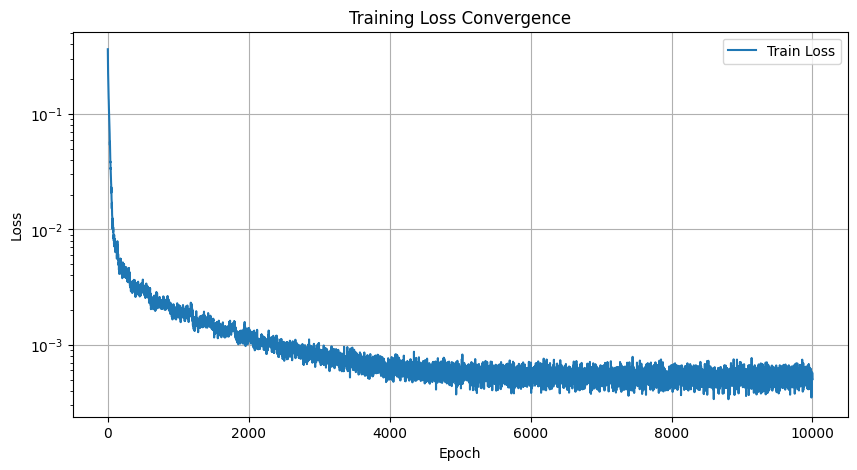

In [84]:
#plot convergence
plt.figure(figsize=(10,5))
plt.plot(model.loss_history, label='Train Loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Convergence')
plt.legend()
plt.grid()
plt.show()

In [86]:
NI.evaluate_model_random_points(model, N=10000, function_case=FUN_NUM, device=torch.device('cpu'))

Model evaluation on N=10000 random points (function_case=3):
  Value errors: mean_abs=3.916925e-05, max_abs=4.438509e-04, L2=5.379753e-05
  Grad-norm errors (|grad|-1): mean_abs=2.056748e-03, max_abs=5.268235e-02, L2=2.805450e-03
  Hessian-diagonal errors (target 0): mean_abs=5.878156e-01, max_abs=5.553493e+00, L2=7.279791e-01


{'N': 10000,
 'function_case': 3,
 'global': {'value_mean_abs_error': 3.916924991544172e-05,
  'value_max_abs_error': 0.0004438508766444419,
  'value_l2_error': 5.379752743068933e-05,
  'grad_norm_mean_abs_error': 0.002056747934974479,
  'grad_norm_max_abs_error': 0.05268235167316515,
  'grad_norm_l2_error': 0.0028054504810043897,
  'hessian_diag_mean_abs_error': 0.5878156293840594,
  'hessian_diag_max_abs_error': 5.553492803855329,
  'hessian_diag_l2_error': 0.727979147151204}}

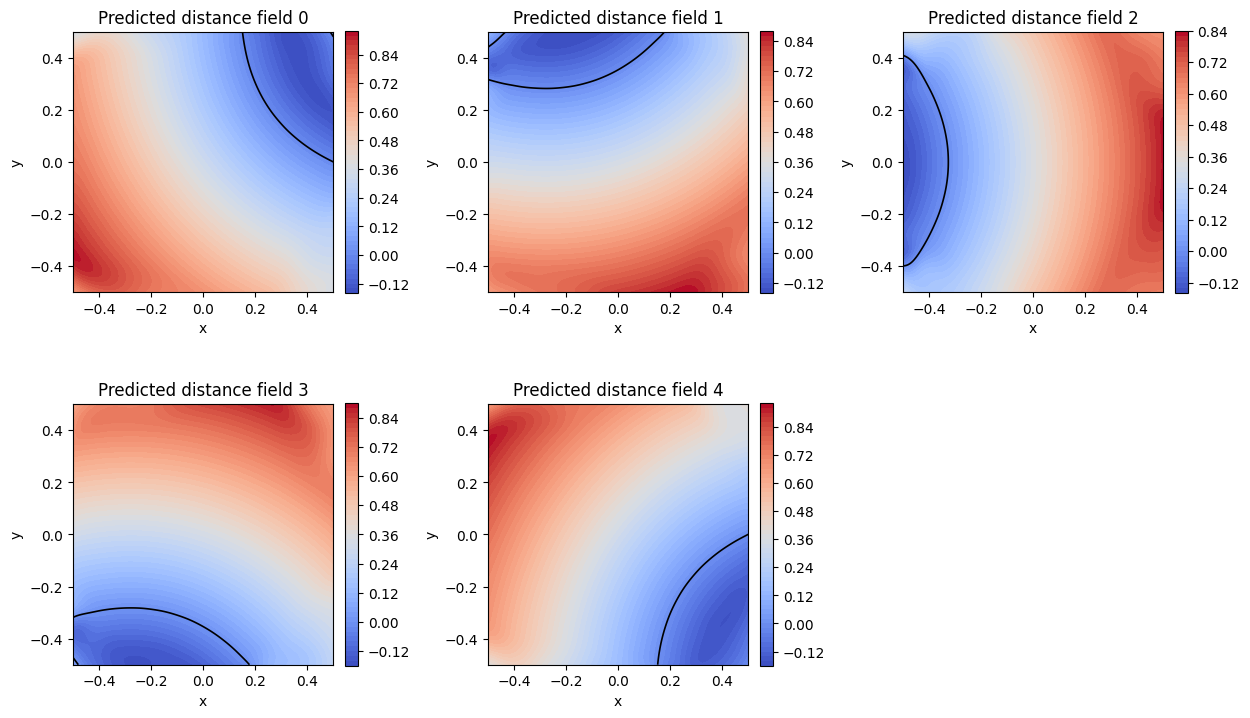

In [87]:
_=NI.plot_nn_distance_fields(model, extent=[-0.5,0.5,-0.5,0.5], mask_outside_domain=False, fun_num=FUN_NUM, device=torch.device('cpu'))

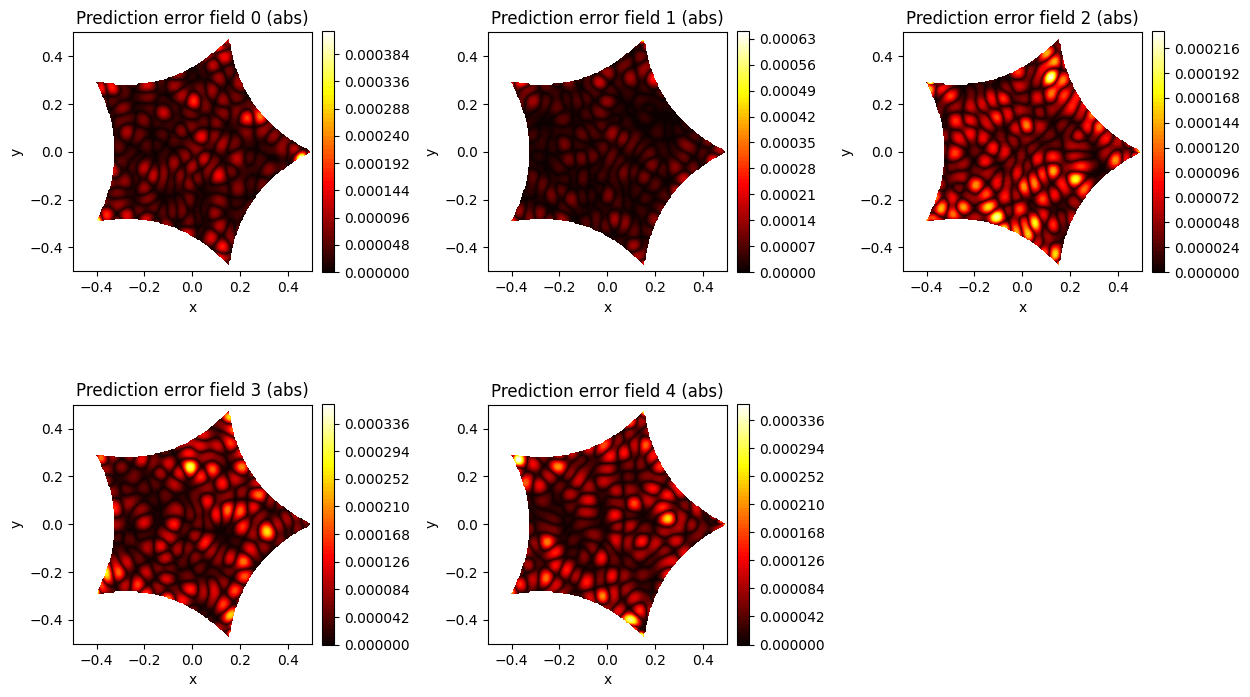

In [88]:
_=NI.plot_nn_prediction_error(model, extent=[-0.5,0.5,-0.5,0.5], fun_num=FUN_NUM, device=torch.device('cpu'))

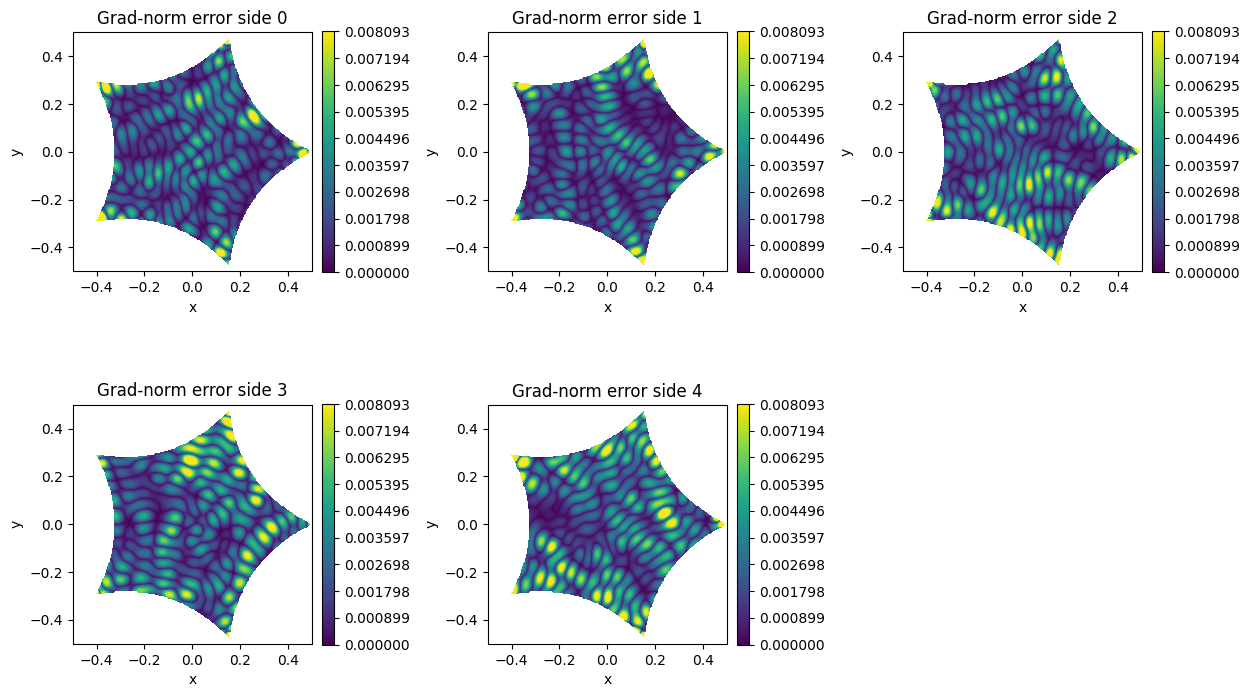

In [92]:
importlib.reload(NI)
_=NI.plot_local_per_side_gradient_error(model, extent=[-0.5,0.5,-0.5,0.5],fun_num=FUN_NUM, device=torch.device('cpu'), cmap='viridis')

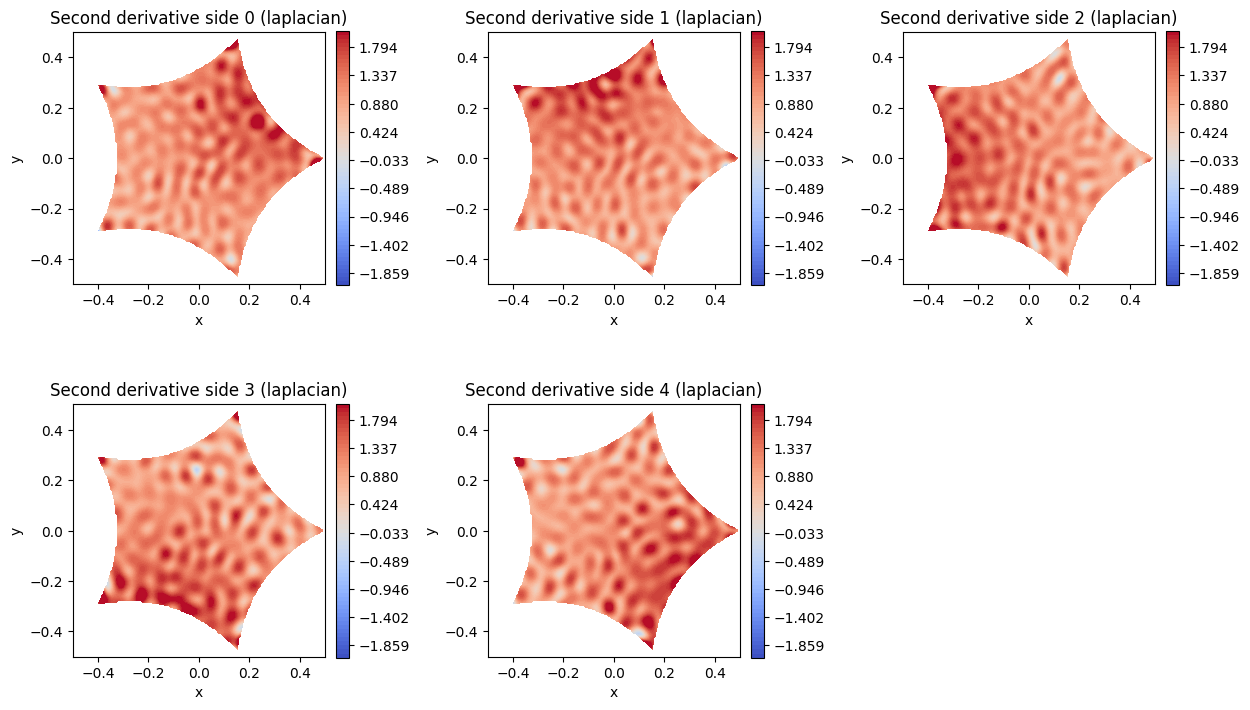

In [94]:
importlib.reload(NI)
_=NI.plot_local_per_side_second_derivative(model, extent=[-0.5,0.5,-0.5,0.5], mask_outside_domain=True, device=torch.device('cpu'),fun_num=FUN_NUM)

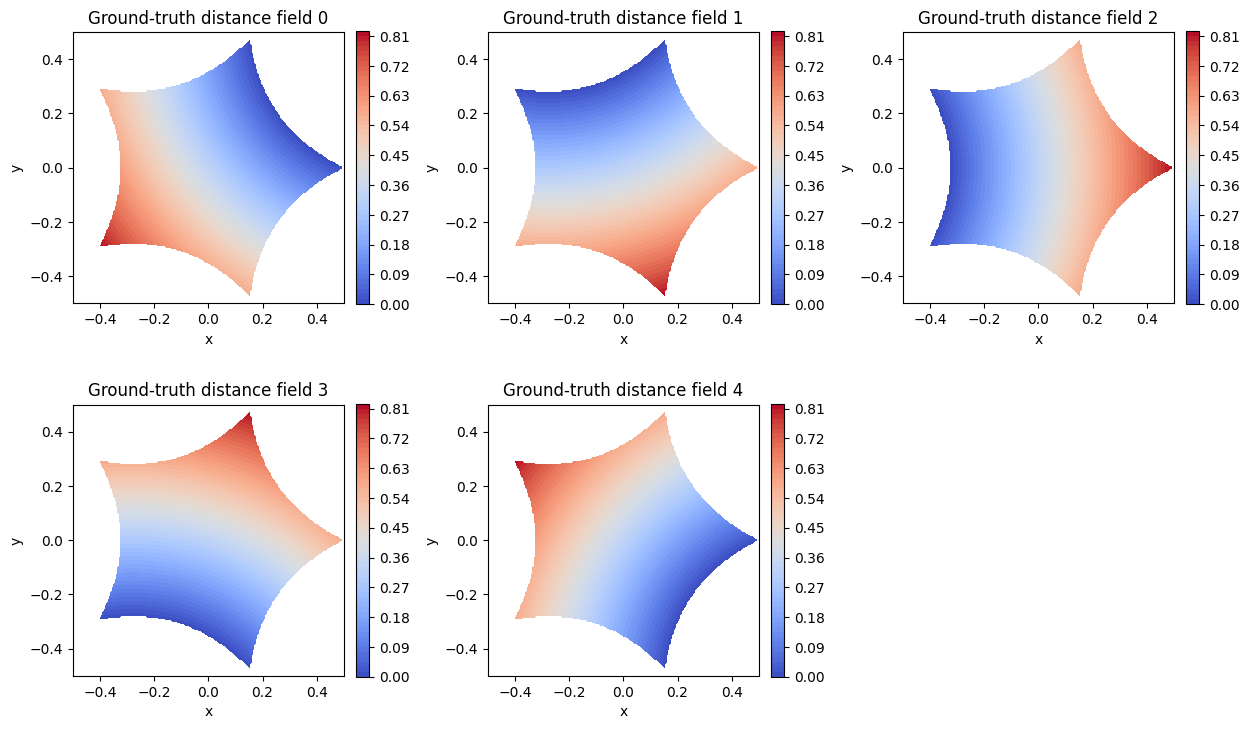

In [26]:
_= NI.plot_ground_truth_distance_fields(fun_num=3, extent=[-0.5,0.5,-0.5,0.5])